In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

import collections

from dm_control import mujoco, viewer, suite
from dm_control.rl import control
from dm_control.suite import base, common
from dm_control.suite.utils import randomizers
from dm_control.utils import rewards
from dm_control.utils import io as resources
from dm_env import specs
import numpy as np
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output

import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [127]:
MIN_NUM_ANCHORS = 32
MAX_NUM_ANCHORS = 32
EPISODE_LENGTH = 400
NUM_RANDOM_STEPS = 400
STATE_SCALE = 10
Z_DIM = 128

DISCOUNT_FACTOR = 0.95

X1_RANGE, X2_RANGE = 0.25 * STATE_SCALE, 0.175 * STATE_SCALE
# X1_RANGE, X2_RANGE = 0.3 * STATE_SCALE, 0.3 * STATE_SCALE

# Reward Generator:

In [128]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [129]:
# fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
# statistics = torch.load('models/reward_generator_mean_std.pth')
# emperical_mean = statistics['emperical_mean']
# emperical_std = statistics['emperical_std']

In [130]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((Z_DIM,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((Z_DIM,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.states_buffer = None
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = Z_DIM
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
        self.resampling_weights = None
        
    def update_states_buffer(self, new_states):

        # num_trajectories, len_trajectory, obs_dim = new_states.shape
        # for i in range(num_trajectories):
        #     if len(self.states_buffer) < self.max_buffer_size:
        #         self.states_buffer.append(new_states[i].cpu())
        #     else:
        #         j = random.randint(0, self.max_buffer_size-1)
        #         self.states_buffer[j] = new_states[i].cpu()
        
        if self.states_buffer is None:
            self.states_buffer = new_states
        else:
            self.states_buffer = torch.concatenate((self.states_buffer, new_states), dim=0)
        
    
    def update_new_states_buffer(self, new_states):
        if self.new_states_buffer is None:
            self.new_states_buffer = new_states
        else:
            self.new_states_buffer = torch.concatenate((self.new_states_buffer, new_states), dim=0)

    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    
    def get_intermediate_anchors(self, anchors, anchors_rewards, num_intermediate_anchors:int):
        
        batch_size, num_anchors = anchors.shape[0], anchors.shape[1]

        intermediate_anchors = []
        intermediate_rewards = []
        for b in range(batch_size):
            # alpha = torch.rand((num_intermediate_anchors, num_anchors-1, 1))
            alpha = torch.linspace(0, 1, num_intermediate_anchors+2)[1:-1].unsqueeze(-1).repeat(1, num_anchors-1).unsqueeze(-1)
            
            x = (1-alpha)*anchors[b, :-1] + alpha*anchors[b, 1:]
            x = x.permute(1, 0, 2)
            
            r = (1-alpha)*anchors_rewards[b, :-1] + alpha*anchors_rewards[b, 1:]
            r = r.permute(1, 0, 2)
            
            x = x.reshape(-1, 2)
            r = r.reshape(-1, 1)
            
            intermediate_anchors.append(x)
            intermediate_rewards.append(r)
            
        intermediate_anchors = torch.stack(intermediate_anchors)
        intermediate_rewards = torch.stack(intermediate_rewards)

        return intermediate_anchors, intermediate_rewards
        # anchors.shape, intermediate_anchors.shape, intermediate_rewards.shape
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, num_intermediate_anchors=10, from_new_states=False):
        assert min_num_anchors <= max_num_anchors <= num_states

        obs_dim = self.obs_dim
        
        all_states = torch.zeros((batch_size, num_states, obs_dim), dtype=torch.float32)
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)
        
        buffer = self.new_states_buffer if from_new_states else self.states_buffer
        assert buffer is not None
        
        num_trajectories, trajectory_length = buffer.shape[0], buffer.shape[1]
        
        # Get anchors:
        # trajectories_idx_ = torch.randint(0, num_trajectories, (batch_size, 1))
        trajectories_idx_ = self.get_importance_sampling_indices(batch_size).unsqueeze(-1)
        trajectories_idx = trajectories_idx_.repeat(1, max_num_anchors).reshape(-1)
        # states_idx       = torch.randint(0, buffer.shape[1], (max_num_anchors*batch_size,))
        states_idx       = torch.linspace(0, trajectory_length-1, max_num_anchors).long().repeat(batch_size)
        anchors = buffer[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)
        all_states[:, :max_num_anchors, :] = anchors
        
        # Get non anchors
        num_non_anchors = num_states - max_num_anchors
        # trajectories_idx = torch.randint(0, buffer.shape[0], (num_non_anchors*batch_size,))
        trajectories_idx = self.get_importance_sampling_indices(num_non_anchors*batch_size)
        states_idx       = torch.randint(0, buffer.shape[1], (num_non_anchors*batch_size,))
        non_anchors = buffer[trajectories_idx, states_idx]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, 2)
        all_states[:, max_num_anchors:, :] = non_anchors
        
            
        rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
        
        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))
        
        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)
        rewards[reward_mask] = torch.linspace(0.3, 1, max_num_anchors).unsqueeze(0).repeat(batch_size, 1).reshape(-1)
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        rewards = rewards.unsqueeze(-1)
        
        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
        
        anchors_rewards = rewards[:, :max_num_anchors]
        
        
        intermediate_anchors, intermediate_rewards = self.get_intermediate_anchors(anchors, anchors_rewards, num_intermediate_anchors=num_intermediate_anchors)
        
        
        return (anchors, anchors_rewards, pad_mask), (all_states, rewards), {
            'trajectories_idx': trajectories_idx_.reshape(-1),
            'intermediate_anchors': intermediate_anchors,
            'intermediate_rewards': intermediate_rewards,
        }
    

        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False, non_anchor_coef=1):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)
        
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, all_states)
        # inter_rewards_pred = self.fre_network.get_reward_pred(w, info['intermediate_anchors'].to(device))
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        
        is_anchor = (rewards != 0)
        # reward_pred_loss = ((rewards_pred - rewards)**2).mean()
        reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean() + ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        # reward_pred_loss += ((inter_rewards_pred - info['intermediate_rewards'].to(device))**2).mean()
        # print(info['intermediate_anchors'].shape, info['intermediate_rewards'].shape, all_states.shape)
        # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred[ is_anchor] - rewards[ is_anchor])**2).mean() + \
                        #    ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred - anchors_rewards)**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info
        }
        
        
    
    def estimate_mean_std(self, steps=10000, num_anchors=None):
        # assert len(self.states_buffer) > 0
        
        self.fre_network.eval()
        
        all_means, all_vars = [], []
        # for  _ in tqdm(range(steps), desc='Estimate_mean_std'):
        for  _ in range(steps):
            (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
                batch_size=1, 
                min_num_anchors=self.min_num_anchors if (num_anchors is None) else num_anchors, 
                max_num_anchors=self.max_num_anchors if (num_anchors is None) else num_anchors,
            )
            anchors = anchors.to(device)
            anchors_rewards = anchors_rewards.to(device)
            pad_mask = pad_mask.to(device)

            with torch.no_grad():
                w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   
                var = torch.exp(2*w_log_std)
            all_means.append(w_mean[0].cpu())
            all_vars.append(var[0].cpu())

        emperical_mean = torch.stack(all_means).mean(dim=0).to(device)

        sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
        emperical_std = sigma_hat ** 0.5
        
        self.emperical_std  = emperical_std
        self.emperical_mean = emperical_mean
        
        return emperical_mean, emperical_std
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int):
        assert self.new_states_buffer is not None
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            from_new_states=True,
            num_states=max_num_anchors+1,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        return eval_z, {'anchors': anchors.cpu(), 'anchors_rewards': anchors_rewards.cpu(), 'get_training_data:info': info}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.train()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = w_mean + eps * torch.exp(w_log_std)
        
        return z, {'anchors': anchors.cpu()}

        


In [131]:
# S = reward_generator.new_states_buffer

In [132]:
# fre_network = FRENetwork(obs_len=2)
# # fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

# reward_generator = RewardGenerator(
#     obs_dim=2,
#     fre_network=fre_network,
#     from_buffer=True,
#     max_buffer_size=10000,
#     min_num_anchors=MIN_NUM_ANCHORS,
#     max_num_anchors=MAX_NUM_ANCHORS,
# )


# # print('Getting new states...')
# # trajectory, random_states = get_new_states(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH, num_random_steps=50)
# # reward_generator.update_new_states_buffer(random_states[..., :2])
# # reward_generator.update_states_buffer    (random_states[..., :2])
# # reward_generator.update_states_buffer    (trajectory['states'][..., :2].reshape(-1, EPISODE_LENGTH, 2))
# # print(len(reward_generator.states_buffer))

# x = torch.rand((50, EPISODE_LENGTH, 2)) * 0.6 - 0.3
# x = x * STATE_SCALE
# reward_generator.states_buffer = S
# reward_generator.new_states_buffer = S
# # reward_generator.states_buffer = x
# # reward_generator.new_states_buffer = x
# losses, pred_losses = [], []


In [133]:
# for i in tqdm(range(10000)):
#     # (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = reward_generator.get_training_data(
#     #     batch_size=256, 
#     #     min_num_anchors=8, 
#     #     max_num_anchors=8,
#     #     num_states=16,
#     #     from_new_states=False
#     # )
    
#     # print(anchors.shape)
#     # print(anchors_rewards.shape)
#     # print(pad_mask.shape)
    
    
    
    
#     loss_dict = reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=8, 
#         max_num_anchors=8,
#         num_states=16,
#         non_anchor_coef=0.5,
#     )
#     losses.append(loss_dict['loss'])
    
#     # break

#     losses.append(loss_dict['loss'])
#     pred_losses.append(loss_dict['kl_loss'])
    
#     # break
    
#     if i % 10 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
#         axs[0].plot(losses)
#         axs[0].set_ylim([0, 0.5])
        
#         axs[1].plot(pred_losses)
#         # axs[1].set_ylim([0, 1])
        
#         plt.show()
        
    
#     # trajectories_idx = torch.randint(0, reward_generator.states_buffer.shape[0], (8*256,))
#     # states_idx =       torch.randint(0, reward_generator.states_buffer.shape[1], (8*256,))
#     # non_anchors = reward_generator.states_buffer[trajectories_idx, states_idx]
#     # non_anchors = non_anchors.reshape(256, 8, 2)
    

In [134]:
# info['get_training_data:info']['intermediate_anchors']

In [135]:
# # x = reward_generator.new_states_buffer.reshape(-1, 2)
# eval_z, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=8, max_num_anchors=8)
# anchors, anchors_rewards = info['anchors'], info['anchors_rewards']


# s = 100
# x1_vals = np.linspace(-0.25, 0.25, s) * STATE_SCALE
# x2_vals = np.linspace(-0.175, 0.175, s) * STATE_SCALE

# # x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
# # x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

# # x1_vals = np.linspace(-0.3, 0.3, s)
# # x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
# # x2_vals = np.linspace(-0.3, 0.3, s)
# # x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



# X1, X2 = np.meshgrid(x1_vals, x2_vals)
# state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# # print(X1.shape, X2.shape)
# s
# state = torch.zeros((s*s, 4), dtype=torch.float32)
# state[:, :2] = torch.tensor(state_x12)
# state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
# state = state.to(device)

# coods = reward_generator.new_states_buffer.reshape(-1, 2).to(device)

# fig, axs = plt.subplots(4, 4, figsize=(20, 16))
# axs = axs.flatten()

# for i in tqdm(range(len(eval_z))):
#     zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
#     with torch.no_grad():
#         r = reward_generator.get_reward(state[..., :2], zi).cpu()
    
    
#     axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=0.5, vmin=0, vmax=1)
#     axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='red', s=anchors_rewards[i, :, 0].reshape(-1).cpu()*100)
#     x = info['get_training_data:info']['intermediate_anchors']
#     axs[i].scatter(x[i, :, 0].cpu(), x[i, :, 1].cpu(), c='red', s=1)

#     add_largest_maze_walls(axs[i])

# plt.show()

In [136]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/fre_network_flexible.pth')

# Jax ENV:

In [137]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class PointMaze(PipelineEnv):

    def __init__(self, path):

        backend='mjx' #'generalized'
        kwargs={}
        
        # self.path = 'mazes/point_mass_maze_empty.xml'
        # self.path = 'mazes/point_mass_maze_hardest.xml'
        self.path = path
        sys = mjcf.load(self.path)
        
        n_frames = 1
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)
        super().__init__(sys=sys, backend=backend, **kwargs)
        
        # path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        
        
    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        _reset_noise_scale = 0.001

        low, hi = -_reset_noise_scale, _reset_noise_scale
        # qpos = self.sys.init_q + jax.random.uniform(
        #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
        # )
        # qpos = self.sys.init_q
        qpos = jnp.array([0.025, 0.])
        # print(self.sys.init_q, qpos)
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))
        
        pipeline_state = self.pipeline_init(qpos, qvel)

        
        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'y_position': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)
    
    def step(self, state: State, action: jax.Array) -> State:
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        obs = self._get_obs(pipeline_state)
        reward = 0

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)
    
    def _get_obs(self, pipeline_state):
        qpos, qvel = pipeline_state.qpos, pipeline_state.qvel
        # return pipeline_state.qpos * STATE_SCALE
        # return jnp.round((pipeline_state.qpos + 0.3) / 0.6 * 32)
        return jnp.concatenate((
            # jnp.round((qpos + 0.3) / 0.6 * 32) * STATE_SCALE,
            qpos * STATE_SCALE,  
            qvel
            ), axis=-1)

In [138]:
from brax.io import torch as io_torch
import random

class TorchWrapper:
    def __init__(self, env, num_envs):
        
        self.env = env
        self.num_envs = num_envs
        self.state_dim = env.observation_size
        self.action_dim = env.action_size
        
        
        self.reset_fn = jax.jit(jax.vmap(env.reset))
        self.step_fn = jax.jit(jax.vmap(env.step))
        
        # self.reset_fn = jax.vmap(env.reset)
        # self.step_fn = jax.vmap(env.step)
        
    
    def reset(self, seed=None):
        
        random_key = jax.random.PRNGKey(random.randint(0, 99999999))
        keys = jax.random.split(random_key, num=self.num_envs)
        # random_key, subkey = jax.random.split(random_key)
        if seed == 1:
            keys = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(keys)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        return observation, reward, done, truncated, {}
        

# PPO:

In [139]:
def compute_gae_parallel(dones, rewards, values, next_values, gamma=DISCOUNT_FACTOR, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    return torch.clip(action, -1, 1)


def collect_trajectories(env, z, model, n_steps, reward_generator: RewardGenerator, num_random_steps=0):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, reward_generator.len_params), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)

    random_states = torch.zeros((env.num_envs, num_random_steps, state_dim), dtype=torch.float32)
    
    state, _ = env.reset()
    

    total_reward = 0
    step_count = 0
    
    # Just to get the dist:
    state = state.to(device)
    with torch.no_grad():
        _, _, _, dist, _ = model(state, z)
    
    
    for s in tqdm(range(n_steps + num_random_steps)):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        if s < n_steps:
            with torch.no_grad():
                action, log_p, state_value, dist, entropy = model(state, z)
                
            next_state, reward, terminated, truncated, _ = env.step(post_process(action).cpu())
            done = terminated * truncated

            # print(state[..., :2].shape, z.shape)
            gm_reward = reward_generator.get_reward(state[..., :2], z)
            # gm_reward = torch.zeros((env.num_envs,))
            
            states[:, s] = state
            zs[:, s] = z.squeeze(-1)
            actions[:, s] = action
            rewards[:, s] = gm_reward.reshape(-1)
            log_ps[:, s] = log_p
            state_values[:, s] = state_value.reshape(-1)
            dones[:, s] = done
        
        
        else: # Increase the standard deviation:
            # print(s)
            dist.scale = torch.exp(torch.full_like(dist.scale, fill_value=model.action_std**2))
            random_action = dist.sample()
            action = random_action
            next_state, reward, terminated, truncated, _ = env.step(post_process(action).cpu())
            
            random_states[:, s - n_steps] = state
            
        
        
        state = next_state
            
        

    
    critic_x = torch.concatenate((next_state, z.cpu()), dim=-1).to(device)
    next_value = model.critic(critic_x).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
        
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, reward_generator.len_params).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
    }
    
    return trajectories, random_states


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories

# shuffled_trajectories = shufffle_trajectory(trajectories)
# z, _ = reward_generator.sample(num_envs)
# trajectory, random_states = collect_trajectories(env, z, model, n_steps=100, reward_generator=reward_generator)

In [140]:
def ppo_optimization(trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_z = trajectories["zs"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            z = traj_z[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, z, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            # print(ratio)
            
            # print(advantage[:10])
            # print(ratio[:10])
            # print(value_loss)
            # print(policy_loss)
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            loss = policy_loss - 2e-7*entropy.mean() + 0.5*value_loss

            # print(return_[:5])
            # print(new_state_value[:5])
            
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    return entropy.mean().item()
            
# ppo_optimization(trajectories, model, optimizer, epochs=1, batch_size=5)
# ppo_optimization(shuffled_trajectory, model, optimizer, epochs=5, batch_size=256)

In [141]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        self.state_dim = state_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_std = action_std
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, obs, fre_idx, action=None):
        x = torch.concat((obs, fre_idx), dim=-1)
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()

In [142]:
def add_largest_maze_walls(ax):
    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * STATE_SCALE

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size
    # torso_x, torso_y = 0, 0

    # Get current axes
    # ax = plt.gca()

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
    rect = patches.Rectangle(
        (-torso_x - block_size, -torso_y - block_size), 
        block_size*width*2, block_size*height*2, 
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)


    # plt.axis('equal')
    # plt.xlim([-torso_x - block_size, -torso_x - block_size + block_size*width*2])
    # plt.ylim([-torso_y - block_size, -torso_y - block_size + block_size*height*2])
    # plt.show()

In [143]:
try:
    env, eval_env
    print('Env already setup')
except NameError:
    # path = 'mazes/point_mass_maze_empty.xml'
    path = 'mazes/point_mass_maze_hardest.xml'
    base_env = PointMaze(path)

    num_envs = 128
    env = TorchWrapper(base_env, num_envs=num_envs)

    # state, _ = env.reset()
    # action = torch.zeros((128, 2)).float()
    # next_state, reward, done, truncated, info = env.step(action)

    eval_num_envs = 16
    eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

Env already setup


In [144]:
def policy_rehearsal(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    z, _ = reward_generator.get_z_from_prior(batch_size=num_envs)
    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy






def train_on_new_states(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = reward_generator.get_training_data(
        batch_size=num_envs, 
        min_num_anchors=MIN_NUM_ANCHORS, 
        max_num_anchors=MAX_NUM_ANCHORS,
        from_new_states=True,
        num_states=MAX_NUM_ANCHORS+1,
    )
    anchors = anchors.to(device)
    anchors_rewards = anchors_rewards.to(device)
    pad_mask = pad_mask.to(device)

    z, _ = reward_generator.get_z_from_anchors(anchors, anchors_rewards, pad_mask)

    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy, {'anchors': anchors, 'trajectory': trajectory, 'get_training_data:info': info}



def visualize_state_distribution(x):
    plt.scatter(x[:, 0].cpu(), x[:, 1].cpu(), s=30, alpha=1)
    plt.xlim([-X1_RANGE, X1_RANGE])
    plt.ylim([-X2_RANGE, X2_RANGE])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.draw()





def filter_only_new_states(new, old, steps):
    assert len(new.shape) == len(old.shape) == 2
    
    obs_len = new.shape[-1]
    
    class DiffModel(nn.Module):
        def __init__(self, ):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(obs_len, 512),
                nn.ReLU(),
                nn.Linear(512, 512),
                nn.ReLU(),
                # nn.Linear(512, 512),
                # nn.ReLU(),
                nn.Linear(512, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.model(x)

    detector = DiffModel()
    detector_optim = torch.optim.Adam(detector.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    detector_losses = []

    # new = reward_generator.new_states_buffer.reshape(-1, 2)
    # old = reward_generator.states_buffer.reshape(-1, 2)

    for i in tqdm(range(steps), desc='filter new trajectories'):
        
        x = torch.concat(
            (
                new[torch.randint(0, new.shape[0], (512,))],
                old[torch.randint(0, old.shape[0], (512,))]
            ), dim=0
        )
        y = torch.concat(
            (
                torch.ones(512, dtype=torch.float32),
                torch.zeros(512, dtype=torch.float32),
            )
        )
        
        pred = detector(x).squeeze(-1)
        loss = criterion(pred, y)
        
        detector_optim.zero_grad()
        loss.backward()
        detector_optim.step()
        
        detector_losses.append(loss.item())
        
        # if i % 10 == 0:
        #     clear_output(True)
        #     plt.plot(detector_losses)
        #     plt.show()
    
    with torch.no_grad():
        old_score = detector(old).detach().cpu().reshape(-1)
        new_score = detector(new).detach().cpu().reshape(-1)
    cond = new_score > 0.8
    to_keep = new[cond]
    
    # plt.scatter(to_keep[:, 0], to_keep[:, 1], c=new_score[cond], vmin=0, vmax=1)
    # plt.scatter(old[:, 0], old[:, 1], c=old_score)
        
    return to_keep, {'loss': detector_losses, 'old_score':old_score, 'new_score':new_score}





def get_new_states(
    iterations: int,
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    reward_generator: RewardGenerator, 
    from_prior: bool,
    num_policy_steps=1000,
    num_random_steps=100,
):
    # Get new states:
    
    
    list_trajectory, list_random_states, list_get_new_states_info = [], [], []

    for _ in tqdm(range(iterations), desc='Get new states', leave=False):
        
        if from_prior:
            z, info = reward_generator.get_z_from_prior(num_envs)
        else:
            z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)
        
        trajectory, random_states = collect_trajectories(
            env, z, model, 
            n_steps=num_policy_steps, 
            reward_generator=reward_generator, 
            num_random_steps=num_random_steps
        )
        
        list_trajectory.append(trajectory)
        list_random_states.append(random_states)
        list_get_new_states_info.append(info)

    trajectory = {key: torch.concat([traj[key] for traj in list_trajectory], dim=0) for key in trajectory}
    info = {key: torch.concat([info[key] for info in list_get_new_states_info], dim=0) if 'info' not in key else [info[key] for info in list_get_new_states_info] for key in info}
    random_states = torch.concat(list_random_states, dim=0)
    
    return trajectory, random_states, info




class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x):
        
        x = x.to(device)
        with torch.no_grad():
            yc = self.current(x)
            yt = self.target(x)
            w = (yc - yt).pow(2).sum(-1).cpu()


        w = w ** 0.8
        w = w / w.sum()

        return w
        
            

In [145]:
fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/fre_network_6.pth'))

reward_generator = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)
# reward_generator.states_buffer = torch.rand((33, 1000, 2)) * 0.6 - 0.3
# empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)

# x = torch.rand((1, 10000, 2)) * 0.6 - 0.3
# x = x * STATE_SCALE
# x = torch.round((x + 0.3) / 0.6 * 32)

# x1_vals = np.linspace(-0.25, 0.25, 100) 
# x2_vals = np.linspace(-0.175, 0.175, 100)
# X1, X2 = np.meshgrid(x1_vals, x2_vals)
# state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# x = torch.tensor(state_x12, dtype=torch.float32) * STATE_SCALE
# x = x.reshape(1, -1, 2)

# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

# reward_generator.new_states_buffer = torch.load('models/new_states_buffer_6.pth')['new_states_buffer']


model = ActorCriticContinuous(
    state_dim=4,
    z_dim=reward_generator.len_params,
    action_dim=2,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)
# model.load_state_dict(torch.load('models/model_6.pth'))


optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

vae_loss, vae_kl_loss = [], []
rewards_list_1, entropies_1 = [], []
rewards_list_2, entropies_2 = [], []

viz_new_state, viz_old_state, viz_random_state, viz_policy_reaches = None, None, None, None
states_buffer_history = []

anchors_list = []
parcoured_states = None

training_steps = 0

In [183]:
def plot_logs():
    clear_output(True)
    fig, axs = plt.subplots(3, 3, figsize=(18, 15))
        
    axs[0, 0].plot(rewards_list_1)
    axs[0, 0].set_title('New functions reward')
    axs[0, 1].plot(entropies_1)
    axs[0, 1].set_title('New functions entropy')
        
    axs[1, 0].plot(rewards_list_2)
    axs[1, 0].set_title('Rehearsal reward')
    axs[1, 1].plot(entropies_2)
    axs[1, 1].set_title('Rehearsal entropy')
        
    axs[2, 0].plot(vae_loss)
    axs[2, 0].set_title('VAE loss')
    axs[2, 0].set_ylim([0, 0.5])
    axs[2, 1].plot(vae_kl_loss)
    axs[2, 1].set_title('VAE KL loss')
    axs[2, 1].set_ylim([0, 2])


    # viz_new_states_buffer = reward_generator.new_states_buffer.reshape(-1, 2)
    # viz_states_buffer = reward_generator.states_buffer.reshape(-1, 2)
    # viz_states_buffer = parcoured_states.reshape(-1, 2)
    
    if viz_old_state is not None:
        axs[0, 2].scatter(viz_old_state[:, 0], viz_old_state[:, 1], c='blue', alpha=0.1, s=10)
    if viz_new_state is not None:
        axs[0, 2].scatter(viz_new_state[:, 0], viz_new_state[:, 1], c='red', alpha=0.1, s=10)
        
    add_largest_maze_walls(axs[0, 2])
    axs[0, 2].set_xlim([-X1_RANGE, X1_RANGE])
    axs[0, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[0, 2].set_title('States coverage')
    
    if viz_new_state is not None:
        axs[1, 2].scatter(viz_new_state[:, 0], viz_new_state[:, 1], c='blue', alpha=0.1, s=10)
    if anchors_list:
        anchors = torch.concat(anchors_list).reshape(-1, 2).cpu().detach()
        axs[1, 2].scatter(anchors[:, 0], anchors[:, 1], marker='x', c='red')
    add_largest_maze_walls(axs[1, 2])
    axs[1, 2].set_xlim([-X1_RANGE, X1_RANGE])
    axs[1, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[1, 2].set_title('Training Anchors')
    
    
    if viz_random_state is not None:
        axs[2, 2].scatter(viz_random_state[:, 0], viz_random_state[:, 1], c='blue', s=10)
    if viz_policy_reaches is not None:
        axs[2, 2].scatter(viz_policy_reaches[:, 0], viz_policy_reaches[:, 1], c='orange', s=10)
    add_largest_maze_walls(axs[2, 2])
    axs[2, 2].set_xlim([-X1_RANGE, X1_RANGE])
    axs[2, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[2, 2].set_title('Policy reaching')
    
    
    plt.show()

In [147]:
# print('Getting new states...')
# trajectory, random_states = get_new_states(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH, num_random_steps=50, from_prior=False)
# reward_generator.update_new_states_buffer(random_states[..., :2])
# reward_generator.update_states_buffer    (random_states[..., :2])
# reward_generator.update_states_buffer    (trajectory['states'][..., :2].reshape(-1, EPISODE_LENGTH, 2))

# x = (torch.rand((100, 50, 2)) * 0.6 - 0.3) * STATE_SCALE
# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

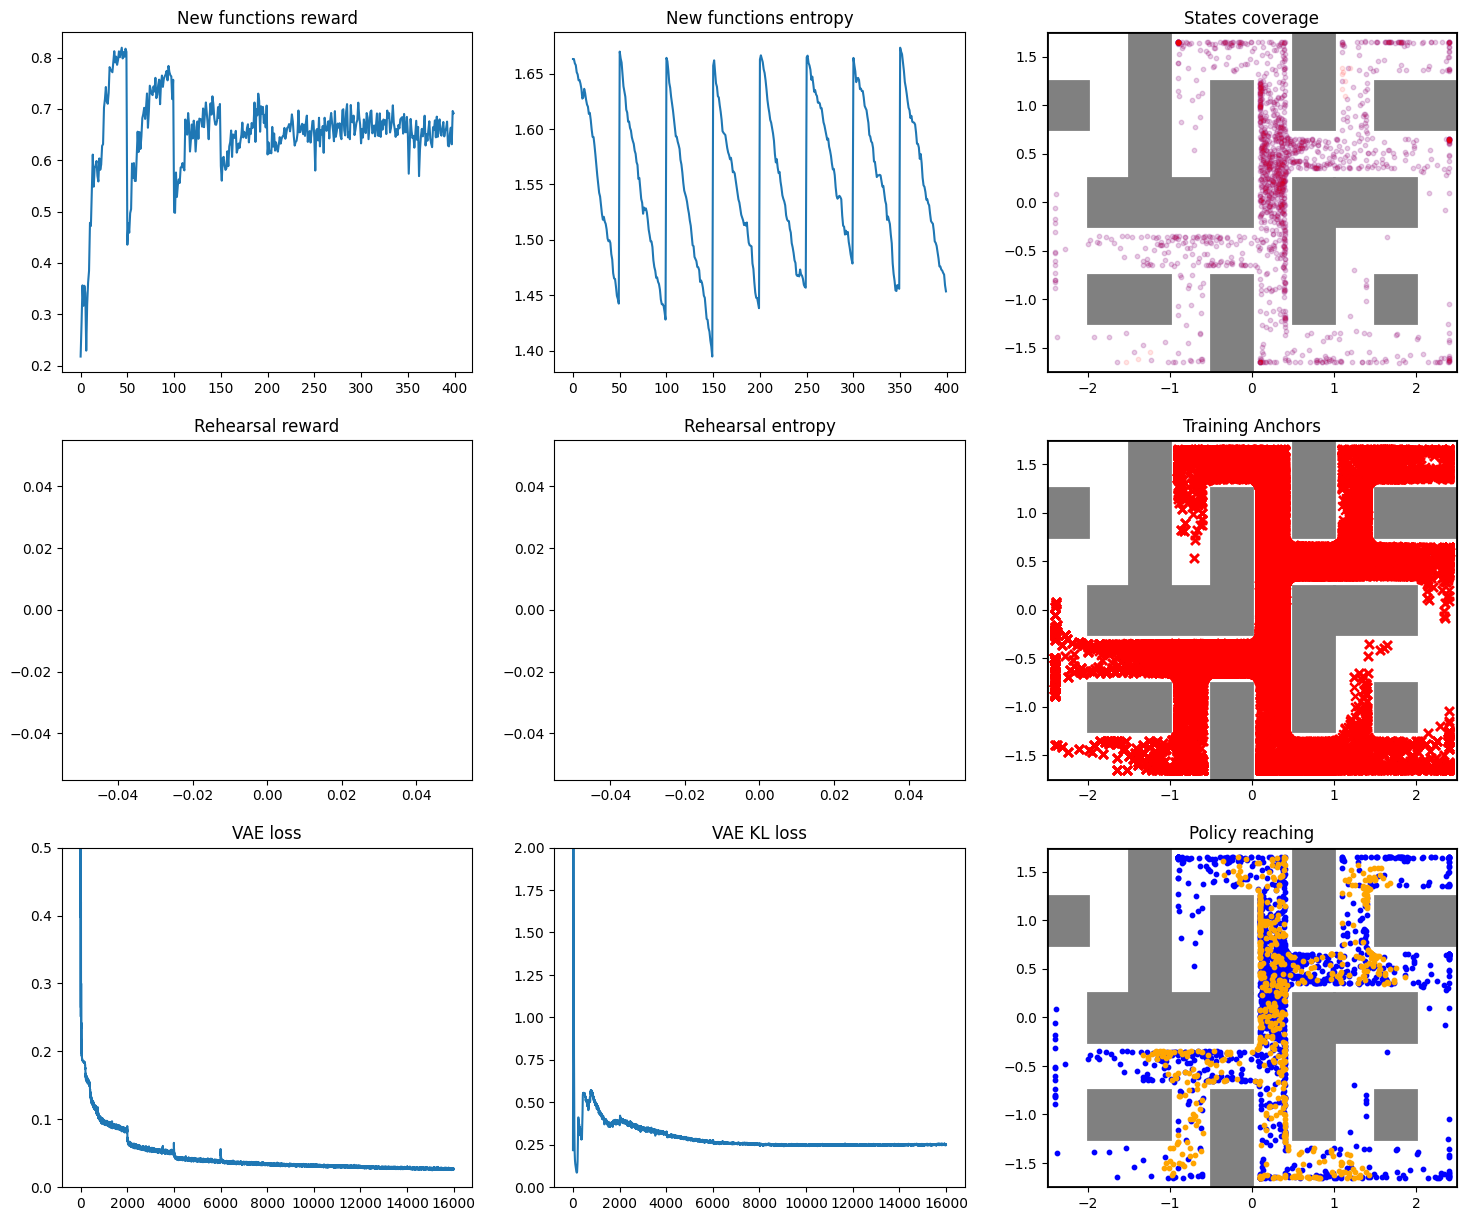

VAE training...


VAE training:   0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [193]:
for epoch in tqdm(range(100)):
    
    ##### Explore new states using random actions ##################################################################
    from_prior = True if (reward_generator.new_states_buffer is None) else False
    print(f'Getting new states... from_prior={from_prior}')
    trajectory, random_states, get_new_states_info = get_new_states(
        5,
        env, model, reward_generator, 
        num_policy_steps=EPISODE_LENGTH, 
        num_random_steps=NUM_RANDOM_STEPS, 
        from_prior=from_prior
    )
    
    
    if reward_generator.new_states_buffer is not None:
        potential_targets = random_states[:, -1, :2]
        old_targets = reward_generator.new_states_buffer[:, -1, :2]
        
        _, filter_info = filter_only_new_states(potential_targets, old_targets, steps=2000)
        to_keep = filter_info['new_score'] > 0.8
    
        parcoured_states_and_random_states = torch.concat(
            (
                trajectory['states'].reshape(-1, EPISODE_LENGTH, 4)[to_keep],
                random_states.reshape(-1, NUM_RANDOM_STEPS, 4)[to_keep]
            ),
            dim=1
        )
    
    
    else:
        parcoured_states_and_random_states = torch.concat(
            (
                trajectory['states'].reshape(-1, EPISODE_LENGTH, 4),
                random_states.reshape(-1, NUM_RANDOM_STEPS, 4)
            ),
            dim=1
        )
    
    
    if reward_generator.new_states_buffer is not None:
        viz_random_state = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
    viz_policy_reaches = trajectory['states'].reshape(-1, EPISODE_LENGTH, 4)[:, -1, :2].reshape(-1, 2)
    
    # reward_generator.update_states_buffer(parcoured_states_and_random_states)
    reward_generator.update_new_states_buffer(parcoured_states_and_random_states[..., :2])
    # reward_generator.new_states_buffer = parcoured_states_and_random_states[..., :2]
    
    
    
    resampler = RNDResampling()
    dataset = reward_generator.new_states_buffer[:, -1, :].reshape(-1, 2)
    resampler_losses = resampler.fit(dataset, epochs=1000)
    resampling_weights = resampler.get_resampling_weights(dataset)
    reward_generator.resampling_weights = resampling_weights
    
    
    
    # Remove the random first please:
    # if training_steps == 1:
    #     reward_generator.new_states_buffer = reward_generator.new_states_buffer[640:]
    
    
    # break
    

    viz_old_state = viz_new_state
    # viz_new_state = trajectory['states'][..., :2].reshape(-1, 2)
    viz_new_state = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
    # viz_random_state = random_states[..., :2].reshape(-1, 2)


    # break
    # continue
    
    plot_logs()

    
    
    ##### train the VAE: ###########################################################################################
    print('VAE training...')
    for _ in tqdm(range(2000), desc='VAE training', leave=False):
        vae_loss_dict = reward_generator.train_step_VAE(
            batch_size=512,
            min_num_anchors=MIN_NUM_ANCHORS,
            max_num_anchors=MAX_NUM_ANCHORS,
            from_new_states=True,
            num_states=64,
            non_anchor_coef=0.5,
        )
        vae_loss.append(vae_loss_dict['loss'])
        vae_kl_loss.append(vae_loss_dict['kl_loss'])    
    plot_logs()


    # ##### Estimate the emperical means and std to train the policy: ################################################
    # print('Mean and std estimation...')
    # empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)    
    
    
    
    ##### Train the policy on new states (Exploration) #############################################################
    print('Policy training on new states...')
    
    model.action_var.data = torch.full((model.action_dim,), model.action_std**2, requires_grad=True, device=device)

    anchors_list = []
    for _ in tqdm(range(50), desc='Policy training', leave=False):
        avg_reward_1, entropy_1, info = train_on_new_states(env, model, optimizer, reward_generator, num_policy_steps=EPISODE_LENGTH)
        anchors_list.append(info['anchors'])
        rewards_list_1.append(avg_reward_1)
        entropies_1.append(entropy_1)
    plot_logs()
    
    
    
    # ##### Train the policy on learned reward functions (Rehearsal) #################################################
    # print('Policy rehearsal...')
    # for _ in range(10):
    #     avg_reward_2, entropy_2 = policy_rehearsal(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH)
    #     rewards_list_2.append(avg_reward_2)
    #     entropies_2.append(entropy_2)
        
    

    # states_buffer_history.append((reward_generator.states_buff    er, reward_generator.new_states_buffer, filtered_new))

    # break
    
    
    training_steps += 1

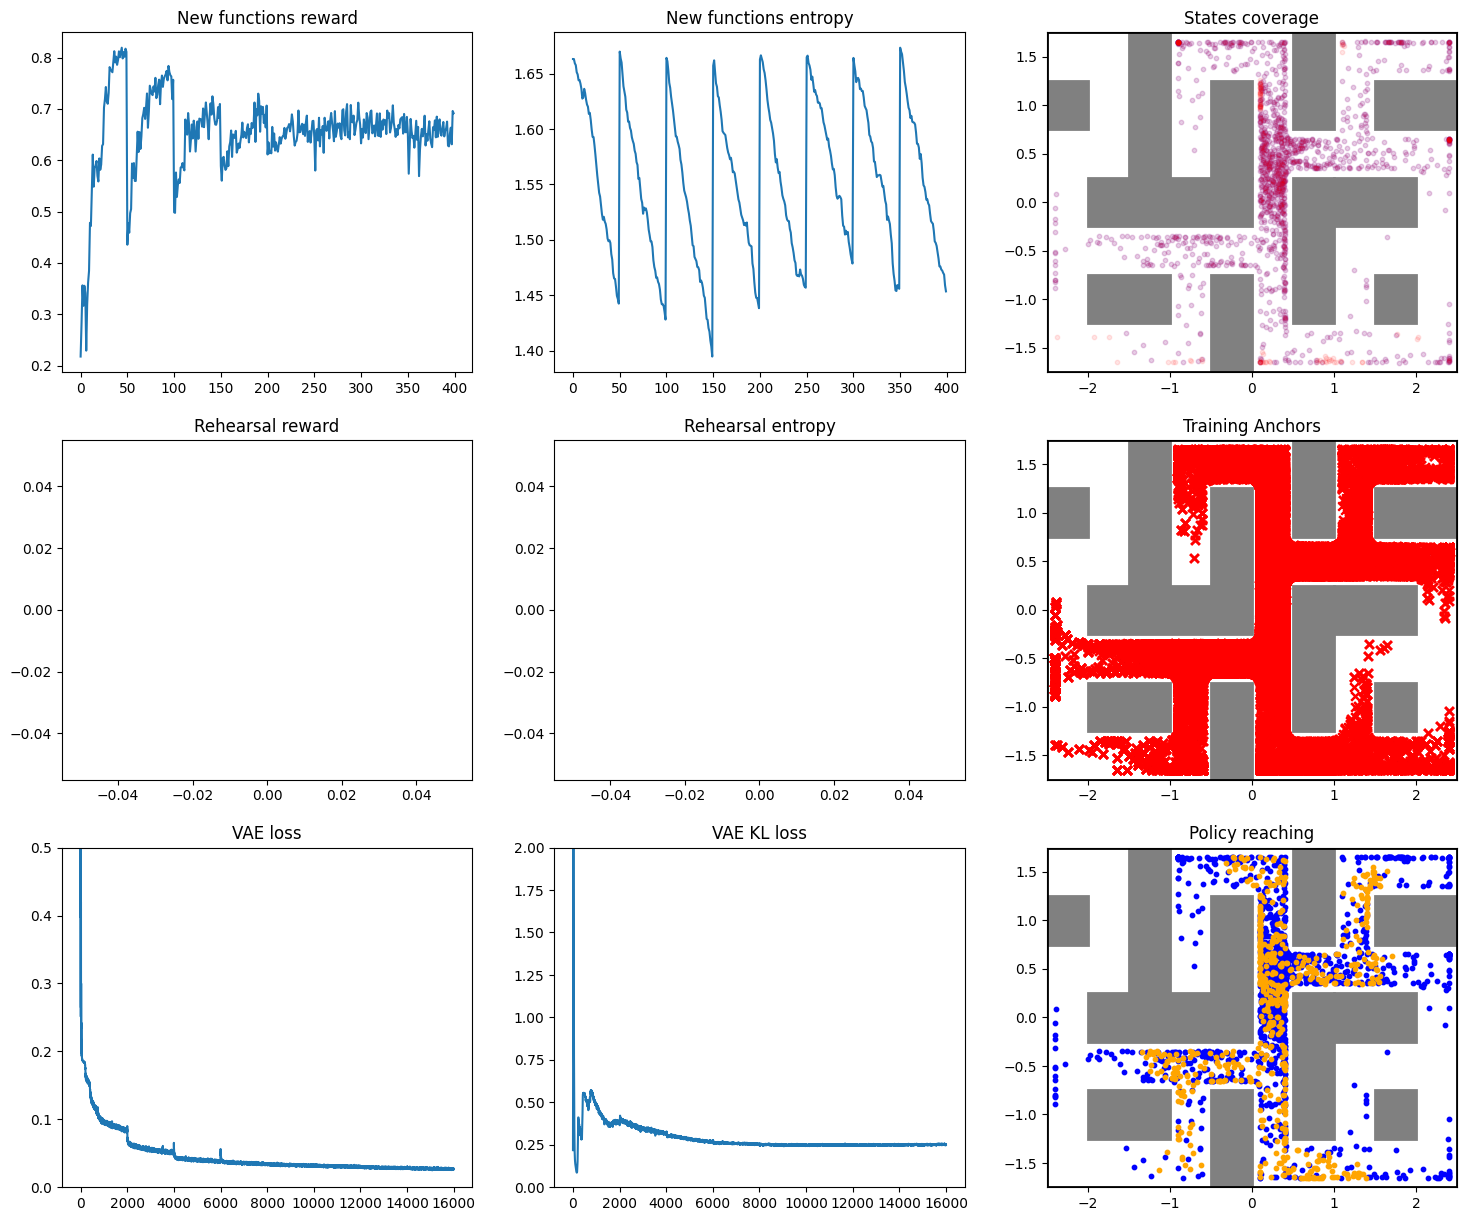

In [184]:
plot_logs()

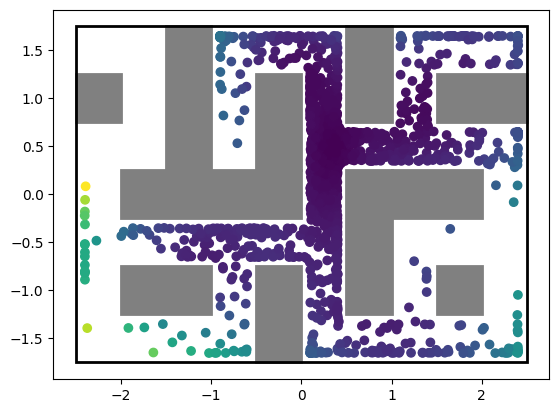

In [185]:
x = reward_generator.new_states_buffer[:, -1, :]
y = reward_generator.resampling_weights

fig, ax = plt.subplots(1, 1)
ax.scatter(x[:, 0], x[:, 1], c=y)
add_largest_maze_walls(ax)

In [ ]:
# S = reward_generator.new_states_buffer

In [ ]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/online_fre_network_3.pth')
# torch.save(model.state_dict(), 'models/online_ppo_model_3.pth')

In [ ]:
cond = (reward_generator.new_states_buffer[:, -1, 1] > 2.5) & (reward_generator.new_states_buffer[:, -1, 0] < -2.5)
cond.sum()

tensor(103)

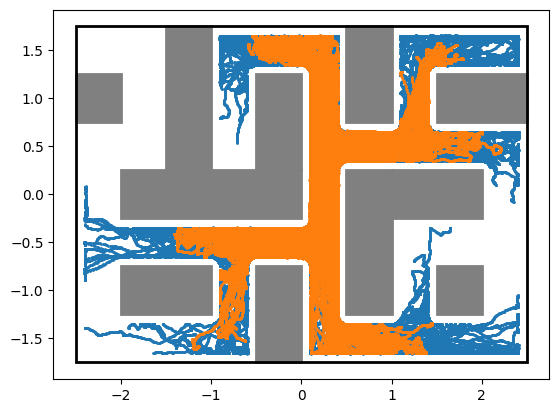

In [186]:
fig, ax = plt.subplots(1, 1)

i = 4

x = reward_generator.new_states_buffer[:, 400:, :]
ax.scatter(x[..., 0], x[..., 1], s=1, alpha=1)

x = reward_generator.new_states_buffer[:, :400, :]
ax.scatter(x[..., 0], x[..., 1], s=1, alpha=1)

add_largest_maze_walls(ax)

# reward_generator.new_states_buffer
# plt.xlim([-2, 2])
# plt.xlim([-2, 2])

In [191]:
# eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)
eval_z, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)

anchors, anchors_rewards = info['anchors'], info['anchors_rewards']

trajectories = []
for _ in tqdm(range(1)):
    trajectories.append(collect_trajectories(eval_env, eval_z, model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

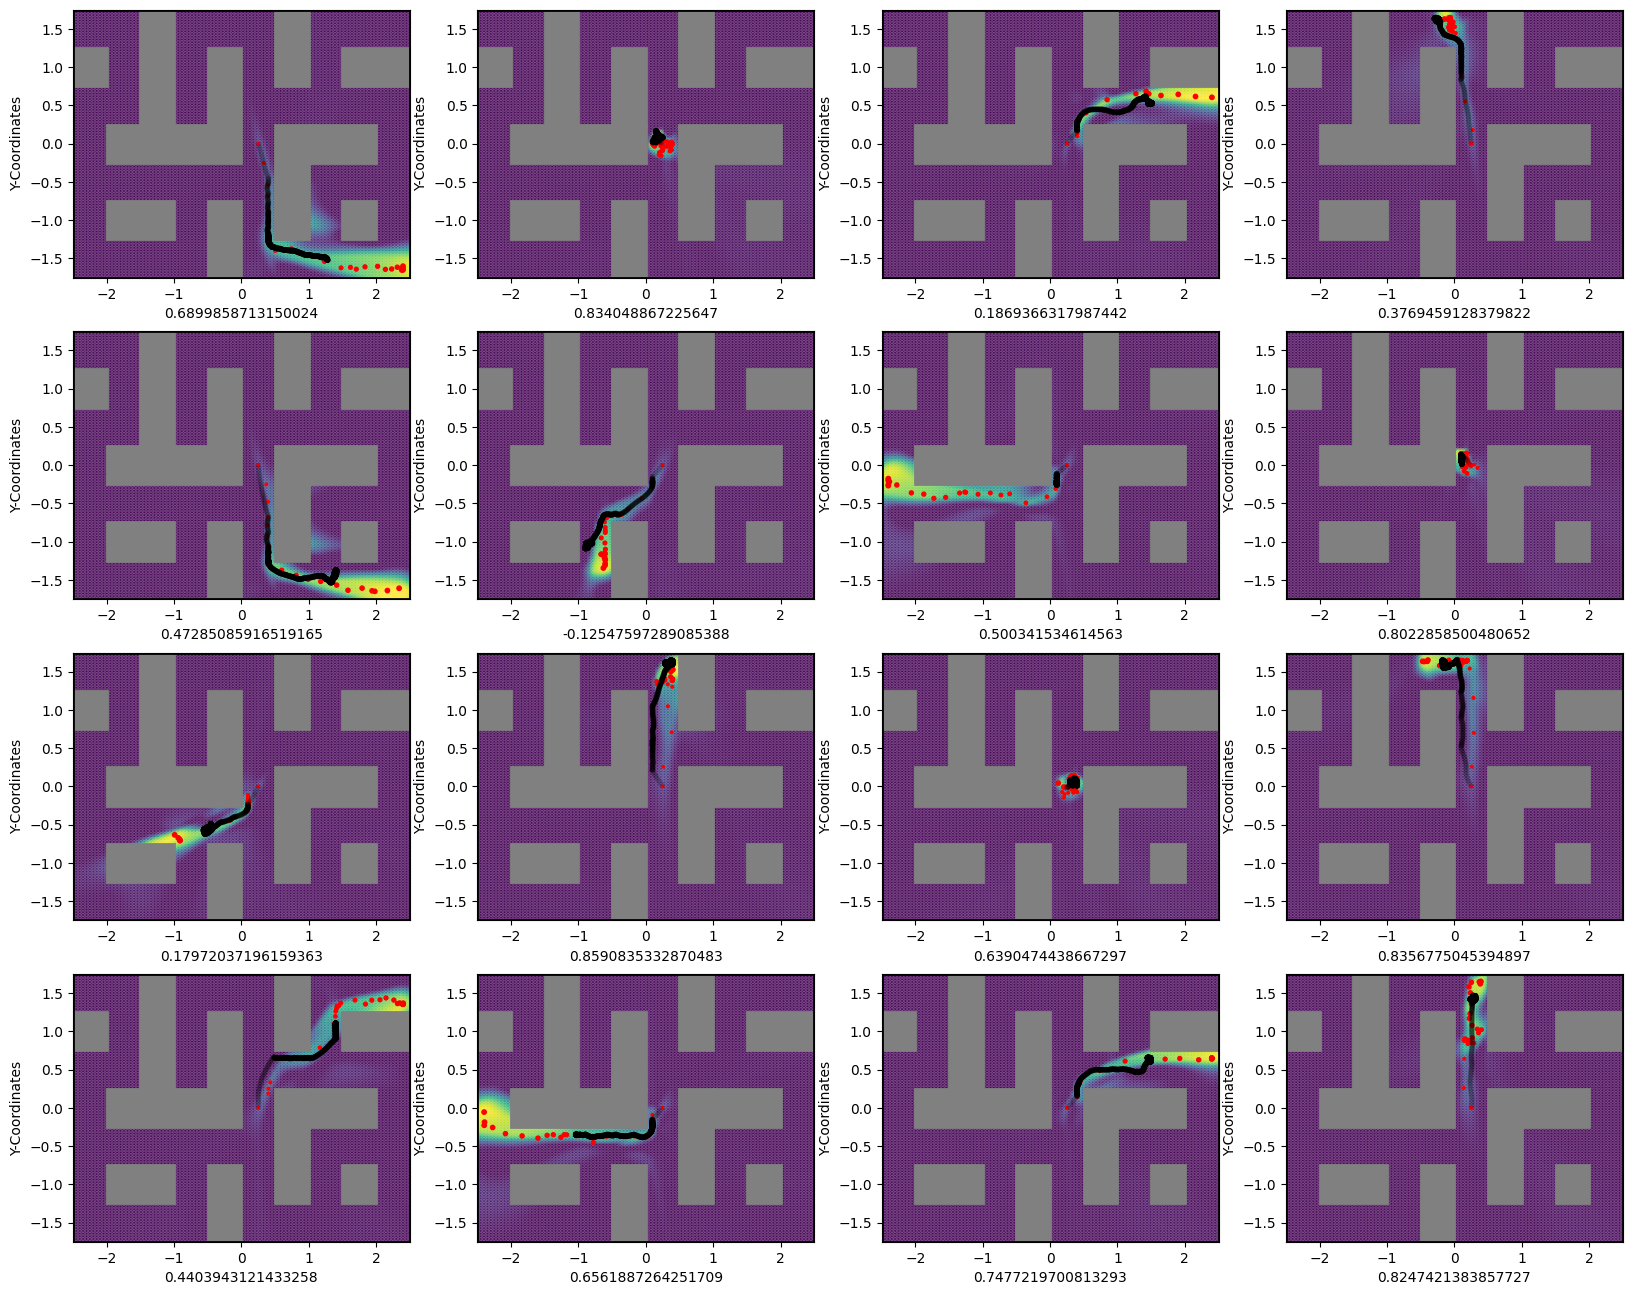

In [192]:
s = 100
x1_vals = np.linspace(-X1_RANGE, X1_RANGE, s)
x2_vals = np.linspace(-X2_RANGE, X2_RANGE, s)

# x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
# x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

# x1_vals = np.linspace(-0.3, 0.3, s)
# x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
# x2_vals = np.linspace(-0.3, 0.3, s)
# x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# print(X1.shape, X2.shape)

state = torch.zeros((s*s, 4), dtype=torch.float32)
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state.to(device)

coods = reward_generator.new_states_buffer.reshape(-1, 2).to(device)

fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in tqdm(range(len(eval_z))):
    zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
    with torch.no_grad():
        r = reward_generator.get_reward(state[..., :2], zi).cpu()
    
    # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
    # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
    axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=0.5, vmin=0.0, vmax=1)
    axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='red', s=anchors_rewards[i, :, 0].reshape(-1).cpu()*10)
    # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
    # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*100)
    
    
    for j in range(len(trajectories)):
        trajectory, _ = trajectories[j]
        coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
        r = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
        axs[i].scatter(coords[:, 0], coords[:, 1], alpha=np.linspace(0.0, 1, len(coords)), s=10, c='black')
        # axs[i].scatter(
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 0], 
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 1],
        #     s=5, c='red'
        # )
        axs[i].set_xlabel("X-Coordinates")  # Change this to your appropriate label
        axs[i].set_xlabel(f"{r}")
        axs[i].set_ylabel("Y-Coordinates")
        # axs[i].set_xlim([-2, 2])
        # axs[i].set_ylim([-2, 2])
    add_largest_maze_walls(axs[i])

plt.show()

---

In [ ]:
eval_z, info = reward_generator.get_z_from_random_anchors(1000, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
anchors, anchors_rewards = info['anchors'], info['anchors_rewards']

In [163]:
weights = []
a = []

for i in tqdm(range(len(eval_z))):
    i = 2
    zi = eval_z[i].unsqueeze(0).repeat(anchors.shape[1], 1)

    with torch.no_grad():
        r = reward_generator.get_reward(anchors[i, ..., :2].to(device), zi).cpu()
        
    w = ((r - anchors_rewards[i])**2).mean()
    weights.append(w)
    a.append(anchors[i])
    
weights = torch.stack(weights)
a = torch.stack(a)

  0%|          | 0/16 [00:00<?, ?it/s]

In [166]:
for j in range(32):
    print(r[j], anchors_rewards[i][j])

tensor([0.1432]) tensor([0.3000])
tensor([0.2562]) tensor([0.3226])
tensor([0.3446]) tensor([0.3452])
tensor([0.3544]) tensor([0.3677])
tensor([0.3848]) tensor([0.3903])
tensor([0.4036]) tensor([0.4129])
tensor([0.4279]) tensor([0.4355])
tensor([0.4358]) tensor([0.4581])
tensor([0.4472]) tensor([0.4806])
tensor([0.4771]) tensor([0.5032])
tensor([0.4903]) tensor([0.5258])
tensor([0.5031]) tensor([0.5484])
tensor([0.5200]) tensor([0.5710])
tensor([0.5557]) tensor([0.5935])
tensor([0.5491]) tensor([0.6161])
tensor([0.6281]) tensor([0.6387])
tensor([0.6543]) tensor([0.6613])
tensor([0.4638]) tensor([0.6839])
tensor([0.7292]) tensor([0.7065])
tensor([0.7478]) tensor([0.7290])
tensor([0.7911]) tensor([0.7516])
tensor([0.8005]) tensor([0.7742])
tensor([0.7966]) tensor([0.7968])
tensor([0.8362]) tensor([0.8194])
tensor([0.8495]) tensor([0.8419])
tensor([0.7972]) tensor([0.8645])
tensor([0.8667]) tensor([0.8871])
tensor([0.9036]) tensor([0.9097])
tensor([0.9696]) tensor([0.9323])
tensor([0.9870

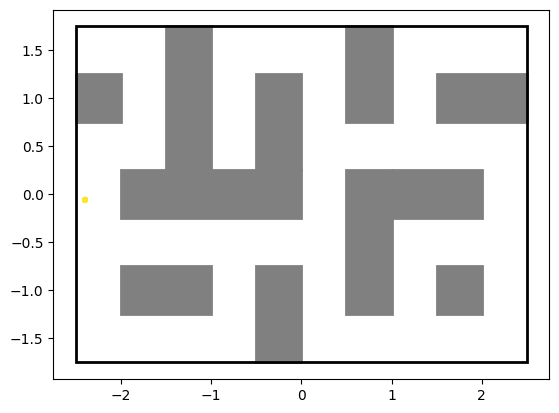

In [164]:
a.shape, weights.shape


fig, ax = plt.subplots(1, 1)
ax.scatter(a[:, -1, 0], a[:, -1, 1], c=weights[:].repeat(1, 1), s=10, alpha=1, vmin=0)
add_largest_maze_walls(ax)

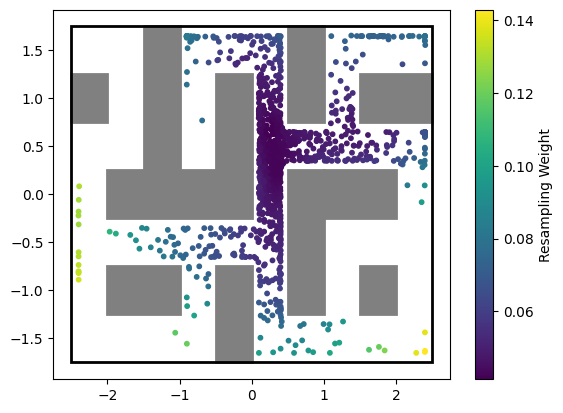

In [181]:
x = reward_generator.new_states_buffer[:, -1, :]
y = reward_generator.resampling_weights

fig, ax = plt.subplots(1, 1)
sc = ax.scatter(x[:, 0], x[:, 1], s=10, c=y ** 0.4, cmap='viridis')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Resampling Weight')
add_largest_maze_walls(ax)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

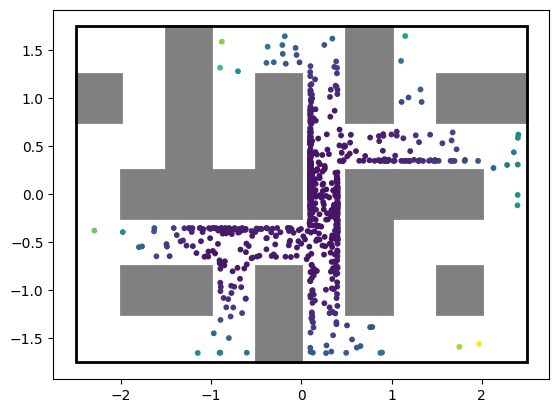

In [ ]:
resampler = RNDResampling()

dataset = reward_generator.new_states_buffer[:, -1, :].reshape(-1, 2)
resampler_losses = resampler.fit(dataset, epochs=1000)

x = reward_generator.new_states_buffer[:, -1, :].reshape(-1, 2)

w = resampler.get_resampling_weights(x)

x = x.cpu()
fig, ax = plt.subplots(1, 1)
ax.scatter(x[:, 0], x[:, 1], s=10, alpha=1, c=w, vmin=0)
add_largest_maze_walls(ax)

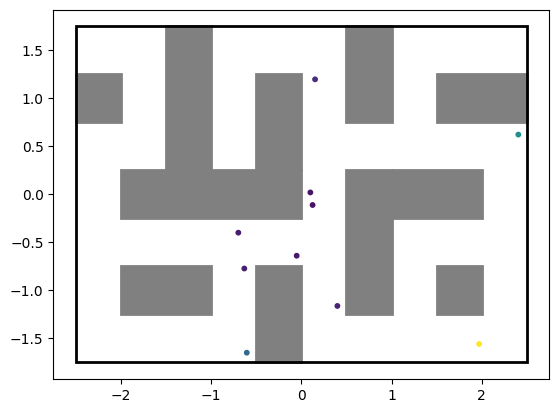

In [ ]:
# Sample with replacement according to weights
indices = torch.multinomial(w, 10, replacement=True)

# Resample x
x_resampled = x[indices]

fig, ax = plt.subplots(1, 1)
ax.scatter(x[indices, 0], x[indices, 1], s=10, alpha=1, c=w[indices], vmin=0)
add_largest_maze_walls(ax)